In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    fbeta_score,
    precision_recall_curve,
    auc,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

plt.style.use("default")
sns.set_context("notebook")

In [2]:
DATA_PATH = "modeling_dataset_v1.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Dataset shape: (401, 23)

Columns:
['company_id', 'financial_year_end', 'label', 'operating_cf_3yr_mean', 'operating_cf_3yr_std', 'investing_cf_3yr_mean', 'investing_cf_3yr_std', 'financing_cf_3yr_mean', 'financing_cf_3yr_std', 'revenue_3yr_mean', 'revenue_3yr_std', 'profit_after_tax_3yr_mean', 'profit_after_tax_3yr_std', 'total_assets_3yr_mean', 'total_assets_3yr_std', 'total_liabilities_3yr_mean', 'total_liabilities_3yr_std', 'equity_3yr_mean', 'equity_3yr_std', 'financing_dependency_ratio', 'pct_years_ocf_negative', 'revenue_3yr_growth', 'profit_3yr_growth']


In [3]:
# Feature / Target Separation
TARGET_COL = "label"
DROP_COLS = ["company_id", "financial_year_end", TARGET_COL]

X = df.drop(columns=DROP_COLS, errors="ignore")
y = df[TARGET_COL]
years = df["financial_year_end"]

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True).round(3))


Feature matrix shape: (401, 20)
Target distribution:
label
0    0.913
1    0.087
Name: proportion, dtype: float64


In [4]:
# Time-based split with explicit TEST set

train_mask = years <= 2020
val_mask = (years >= 2021) & (years <= 2023)
test_mask = years >= 2024

X_train = X[train_mask]
y_train = y[train_mask]

X_val = X[val_mask]
y_val = y[val_mask]

X_test = X[test_mask]
y_test = y[test_mask]

print("=== DATA SPLIT SUMMARY ===")
print(f"Train (≤2020): {len(X_train)} rows")
print(f"Validation (2021–2023): {len(X_val)} rows")
print(f"Test (≥2024): {len(X_test)} rows")
print(f"Total used: {len(X_train) + len(X_val) + len(X_test)}")


=== DATA SPLIT SUMMARY ===
Train (≤2020): 122 rows
Validation (2021–2023): 208 rows
Test (≥2024): 71 rows
Total used: 401


In [5]:
# Feature Scalling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


In [6]:
# Train Logistic Regression
model = LogisticRegression(
    class_weight="balanced",
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model trained successfully.")


Model trained successfully.


In [7]:
# Validation Prediction
y_pred = model.predict(X_val_scaled)
y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]


In [8]:
# Evaluation
precision_risky = precision_score(y_val, y_pred, pos_label=1)
recall_risky = recall_score(y_val, y_pred, pos_label=1)
f2_score = fbeta_score(y_val, y_pred, beta=2, pos_label=1)

precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_pred_proba)
pr_auc = auc(recall_curve, precision_curve)

print("=== PRIMARY METRICS (Risky Class) ===")
print(f"Recall     : {recall_risky:.3f}")
print(f"Precision  : {precision_risky:.3f}")

print("\n=== SECONDARY METRICS ===")
print(f"F2-Score   : {f2_score:.3f}")
print(f"PR-AUC     : {pr_auc:.3f}")


=== PRIMARY METRICS (Risky Class) ===
Recall     : 0.889
Precision  : 0.640

=== SECONDARY METRICS ===
F2-Score   : 0.825
PR-AUC     : 0.874


In [9]:
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_val, y_pred))

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       190
           1       0.64      0.89      0.74        18

    accuracy                           0.95       208
   macro avg       0.81      0.92      0.86       208
weighted avg       0.96      0.95      0.95       208



In [10]:
# Evaluate on TEST set (≥ 2024)

X_test_scaled = scaler.transform(X_test)

y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import precision_score, recall_score, fbeta_score, precision_recall_curve, auc

test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f2 = fbeta_score(y_test, y_test_pred, beta=2, pos_label=1)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_test_proba)
test_pr_auc = auc(recall_curve, precision_curve)

print("=== TEST SET PERFORMANCE (≥ 2024) ===")
print(f"Recall (Risky):    {test_recall:.3f}")
print(f"Precision (Risky): {test_precision:.3f}")
print(f"F2-score:          {test_f2:.3f}")
print(f"PR-AUC:            {test_pr_auc:.3f}")


=== TEST SET PERFORMANCE (≥ 2024) ===
Recall (Risky):    0.833
Precision (Risky): 0.714
F2-score:          0.806
PR-AUC:            0.873


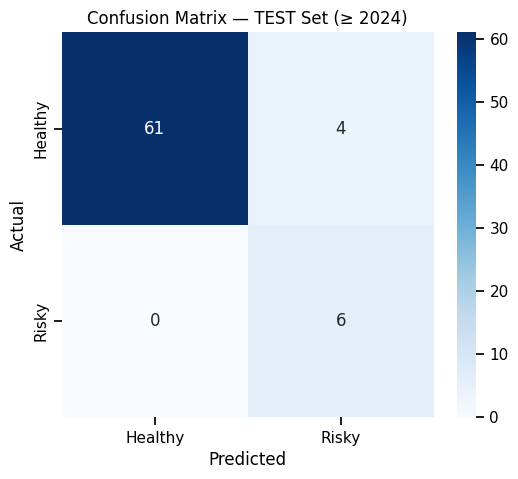

In [13]:
# confusion matrix on test set
from sklearn.metrics import confusion_matrix

THRESHOLD = 0.23
y_test_pred_thr = (y_test_proba >= THRESHOLD).astype(int)

cm_test = confusion_matrix(y_test, y_test_pred_thr)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy", "Risky"],
    yticklabels=["Healthy", "Risky"]
)

plt.title("Confusion Matrix — TEST Set (≥ 2024)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


In [14]:
# saving test results
test_predictions = pd.DataFrame({
    'company_id': df.loc[y_test.index, 'company_id'],
    'financial_year_end': df.loc[y_test.index, 'financial_year_end'],
    'true_label': y_test.values,
    'lr_pred': y_test_pred,
    'lr_pred_proba': y_test_proba
})

test_predictions.to_csv("logreg_test_predictions_2024_plus.csv", index=False)

print("Saved test predictions to logreg_test_predictions_2024_plus.csv")


Saved test predictions to logreg_test_predictions_2024_plus.csv


In [16]:
joblib.dump(model, "logistic_regression_model.joblib")

['logistic_regression_model.joblib']

In [11]:
feature_importance = (
    pd.DataFrame({
        "feature": X.columns,
        "coefficient": model.coef_[0],
        "abs_coefficient": np.abs(model.coef_[0])
    })
    .sort_values("abs_coefficient", ascending=False)
)


In [12]:
print(feature_importance.sort_values(by ='coefficient' ))

                       feature  coefficient  abs_coefficient
0        operating_cf_3yr_mean    -0.684278         0.684278
7              revenue_3yr_std    -0.286838         0.286838
6             revenue_3yr_mean    -0.282864         0.282864
5         financing_cf_3yr_std    -0.093974         0.093974
10       total_assets_3yr_mean    -0.057128         0.057128
12  total_liabilities_3yr_mean    -0.057128         0.057128
9     profit_after_tax_3yr_std    -0.051703         0.051703
1         operating_cf_3yr_std     0.000699         0.000699
18          revenue_3yr_growth     0.026391         0.026391
8    profit_after_tax_3yr_mean     0.041799         0.041799
14             equity_3yr_mean     0.078416         0.078416
15              equity_3yr_std     0.147580         0.147580
11        total_assets_3yr_std     0.195445         0.195445
13   total_liabilities_3yr_std     0.195445         0.195445
2        investing_cf_3yr_mean     0.282239         0.282239
19           profit_3yr_

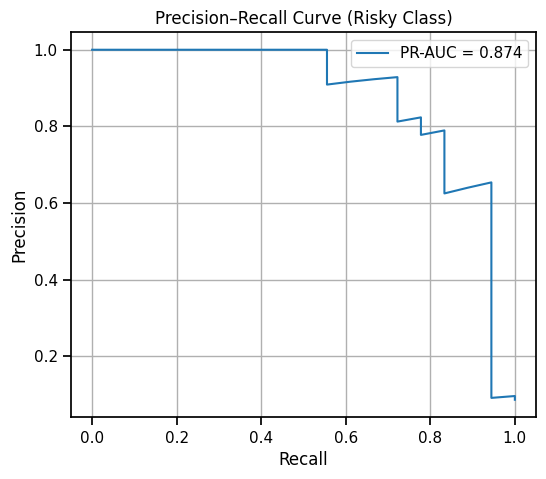

In [12]:
plt.figure(figsize=(6, 5))
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Risky Class)")
plt.legend()
plt.grid(True)
plt.show()


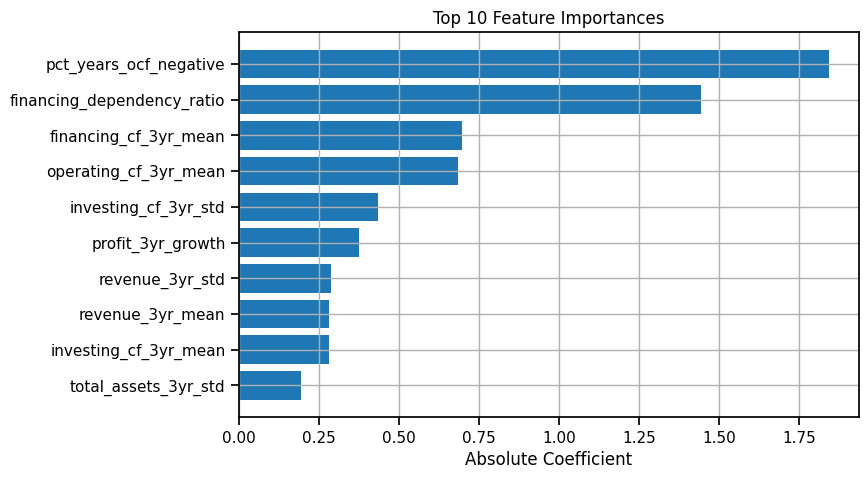

In [13]:
top_n = 10
top_features = feature_importance.head(top_n)

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["abs_coefficient"])
plt.gca().invert_yaxis()
plt.xlabel("Absolute Coefficient")
plt.title("Top 10 Feature Importances")
plt.grid(True)
plt.show()


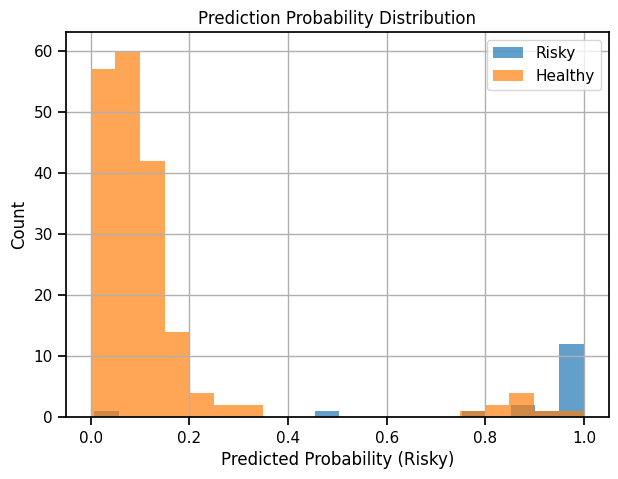

In [14]:
plt.figure(figsize=(7, 5))

plt.hist(
    y_pred_proba[y_val == 1],
    bins=20,
    alpha=0.7,
    label="Risky"
)

plt.hist(
    y_pred_proba[y_val == 0],
    bins=20,
    alpha=0.7,
    label="Healthy"
)

plt.xlabel("Predicted Probability (Risky)")
plt.ylabel("Count")
plt.title("Prediction Probability Distribution")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
val_results = pd.DataFrame({
    "company_id": df.loc[y_val.index, "company_id"],
    "financial_year_end": df.loc[y_val.index, "financial_year_end"],
    "true_label": y_val.values,
    "predicted_label": y_pred,
    "predicted_risk_probability": y_pred_proba
})

val_results.to_csv("logistic_regression_validation_predictions.csv", index=False)

val_results.head()


,company_id,financial_year_end,true_label,predicted_label,predicted_risk_probability
0,ABB,2021,0,0,0.198383
1,ABB,2022,0,0,0.153901
2,ABB,2023,0,0,0.138344
4,ADANIENSOL,2021,0,0,0.234824
5,ADANIENSOL,2022,0,0,0.168450


In [17]:
# Precision–Recall vs Threshold analysis
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_val, y_pred_proba
)

# precision_recall_curve returns len(thresholds) = len(precision) - 1
thresholds = np.append(thresholds, 1.0)

pr_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision_curve,
    "recall": recall_curve
})

pr_df.head()


,threshold,precision,recall
0,0.000031,0.086538,1.0
1,0.000077,0.086957,1.0
2,0.000186,0.087379,1.0
3,0.000225,0.087805,1.0
4,0.000305,0.088235,1.0


In [18]:
print(pr_df.iloc[::25])

     threshold  precision    recall
0     0.000031   0.086538  1.000000
25    0.013109   0.092896  0.944444
50    0.041183   0.107595  0.944444
75    0.070552   0.127820  0.944444
100   0.087140   0.157407  0.944444
125   0.114562   0.204819  0.944444
150   0.135676   0.293103  0.944444
175   0.231181   0.515152  0.944444
200   0.998717   1.000000  0.444444


In [19]:
# Scenario 1: Recall ≥ 0.95 → What Precision?
high_recall_df = pr_df[pr_df["recall"] >= 0.95]

best_high_recall = high_recall_df.iloc[0]

print("=== Recall ≥ 0.95 Scenario ===")
print(f"Threshold : {best_high_recall['threshold']:.3f}")
print(f"Recall    : {best_high_recall['recall']:.3f}")
print(f"Precision : {best_high_recall['precision']:.3f}")


=== Recall ≥ 0.95 Scenario ===
Threshold : 0.000
Recall    : 1.000
Precision : 0.087


In [20]:
# Scenario 2: Precision ≥ 0.70 → What Recall?
high_precision_df = pr_df[pr_df["precision"] >= 0.70]

best_high_precision = high_precision_df.iloc[-1]

print("=== Precision ≥ 0.70 Scenario ===")
print(f"Threshold : {best_high_precision['threshold']:.3f}")
print(f"Precision : {best_high_precision['precision']:.3f}")
print(f"Recall    : {best_high_precision['recall']:.3f}")


=== Precision ≥ 0.70 Scenario ===
Threshold : 1.000
Precision : 1.000
Recall    : 0.000


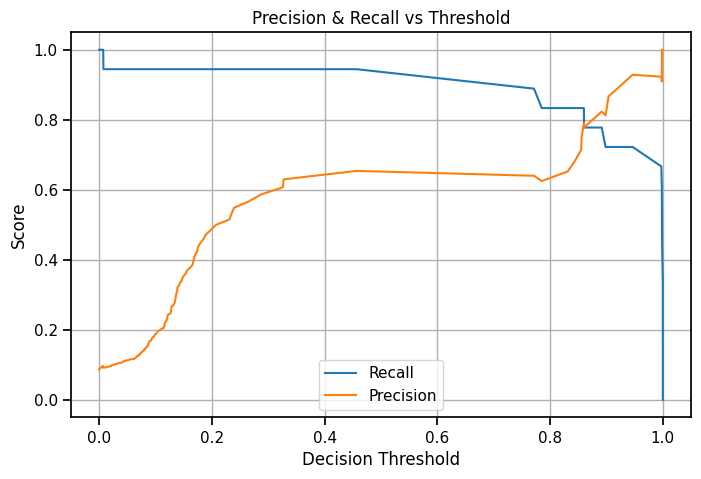

In [21]:
# Visualize threshold trade off
plt.figure(figsize=(8, 5))
plt.plot(pr_df["threshold"], pr_df["recall"], label="Recall")
plt.plot(pr_df["threshold"], pr_df["precision"], label="Precision")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


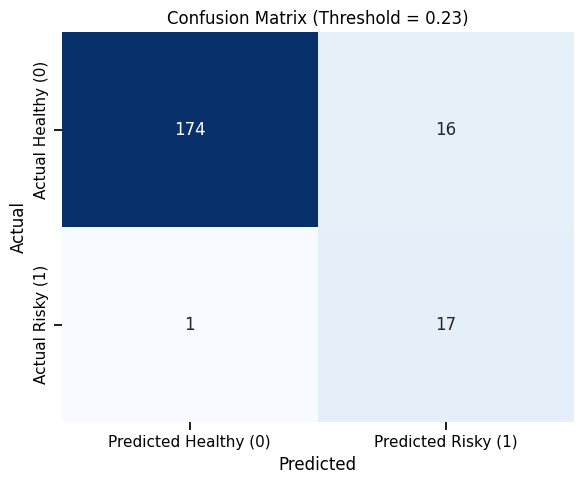

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Use the same threshold as evaluation
THRESHOLD = 0.23

# Convert probabilities to class predictions
y_val_pred = (y_pred_proba >= THRESHOLD).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Create labeled DataFrame
cm_df = pd.DataFrame(
    cm,
    index=["Actual Healthy (0)", "Actual Risky (1)"],
    columns=["Predicted Healthy (0)", "Predicted Risky (1)"]
)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title(f"Confusion Matrix (Threshold = {THRESHOLD})")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


In [24]:
print("Full dataset size:", len(df))
print("Training set size:", len(y_train))
print("Validation set size:", len(y_val))


Full dataset size: 401
Training set size: 122
Validation set size: 208
